In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

In [2]:
class Equilibrium:
    
    R = 8.314
    
    def __init__(self, DrH0, K0, Ea, k0, A0=1.):
        self.DrH0 = DrH0
        self.K0 = K0
        self.Ea = Ea
        self.k0 = k0
        self.A0 = A0
        
    def K(self, T):
        return self.K0 * np.exp(- self.DrH0 / (self.R * T))
    
    def k(self, T):
        return self.k0 * np.exp(- self.Ea / (self.R * T))
    
    def xe(self, T):
        return self.K(T) / (1. + self.K(T))
        
    def v(self, T, x):
        return self.A0 * self.k(T) * (1. - x / self.xe(T))
    
    def x_otp(self, T):
        return self.Ea * self.K(T) / (self.Ea - self.DrH0 + self.Ea * self.K(T))
    
    def x_pftr(self, T, tau):
        return self.xe(T) * (1. - np.exp(- tau * self.k(T) / self.xe(T)))
    
    def x_cstr(self, T, tau):
        return tau * self.k(T) * self.xe(T) / (self.xe(T) + tau * self.k(T))
    
    def levenspiel(self, x, T):
        return 1. / self.v(T, x)
    
    def levenspiel_otp(self, x):
        return (self.Ea - self.DrH0) / (self.DrH0 * self.A0 * self.k0 * (x - 1.) * np.power(- (self.Ea - self.DrH0) * x / (self.Ea * self.K0 * (x - 1.)), self.Ea / self.DrH0))

In [3]:
Tlin = np.linspace(250, 500, 500)

In [4]:
model = Equilibrium(-75300, 0.18955e-10, 48721, 530991)

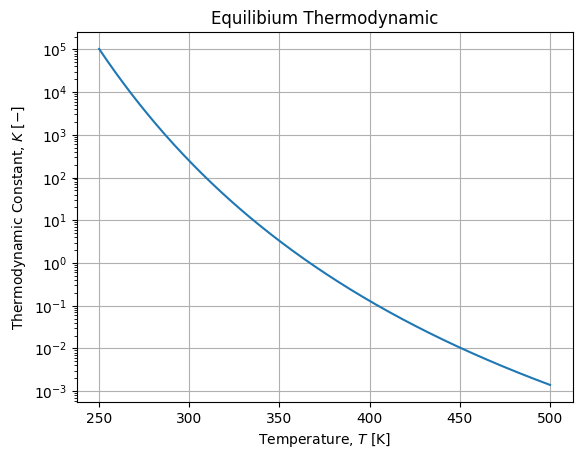

In [5]:
fig, axe = plt.subplots()
axe.semilogy(Tlin, model.K(Tlin))
axe.set_title("Equilibium Thermodynamic")
axe.set_xlabel(r"Temperature, $T$ $[\mathrm{K}]$")
axe.set_ylabel(r"Thermodynamic Constant, $K$ $[-]$")
axe.grid()

In [6]:
vlevels = np.logspace(-6, -1, 15)
xlin = np.linspace(0., 1., 500)
T, X = np.meshgrid(Tlin, xlin)
xisov = model.v(T, X)

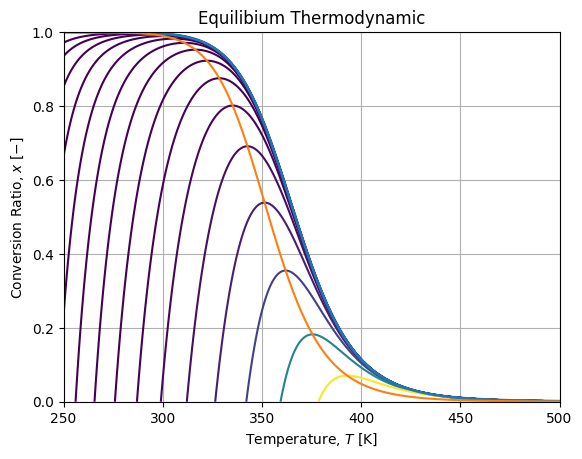

In [7]:
fig, axe = plt.subplots()
c = axe.contour(T, X, xisov, vlevels)
axe.plot(Tlin, model.xe(Tlin), linewidth=2.)
axe.plot(Tlin, model.x_otp(Tlin))
axe.set_title("Equilibium Thermodynamic")
axe.set_xlabel(r"Temperature, $T$ $[\mathrm{K}]$")
axe.set_ylabel(r"Conversion Ratio, $x$ $[-]$")
axe.grid()

In [8]:
taus = np.logspace(1, 4, 10)

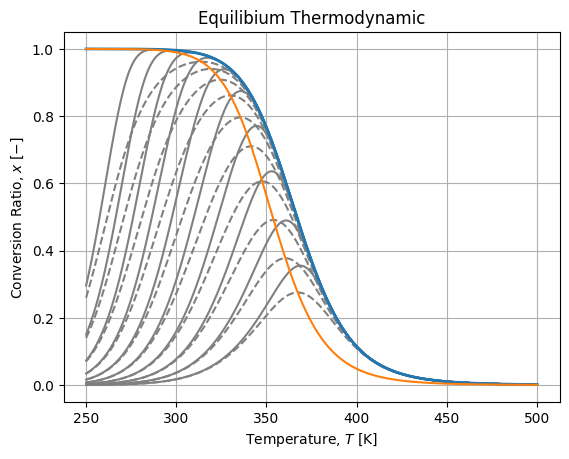

In [9]:
fig, axe = plt.subplots()
for tau in taus:
    axe.plot(Tlin, model.x_pftr(Tlin, tau), color="gray")
    axe.plot(Tlin, model.x_cstr(Tlin, tau), linestyle="--", color="gray")
axe.plot(Tlin, model.xe(Tlin), linewidth=2.)
axe.plot(Tlin, model.x_otp(Tlin))
axe.set_title("Equilibium Thermodynamic")
axe.set_xlabel(r"Temperature, $T$ $[\mathrm{K}]$")
axe.set_ylabel(r"Conversion Ratio, $x$ $[-]$")
axe.grid()

In [10]:
Tmax = 273.15 + 95.

In [22]:
xmax = model.x_otp(Tmax)

In [26]:
xlin2 = np.linspace(0, xmax, 200)
xlin3 = np.linspace(xmax, 0.80, 200)

In [28]:
L2 = model.levenspiel(xlin2, Tmax)
L3 = model.levenspiel_otp(xlin3)

In [36]:
tau2, _ = integrate.quad(model.levenspiel, xlin2[0], xlin2[-1], args=(Tmax,))
tau3, _ = integrate.quad(model.levenspiel_otp, xlin3[0], xlin3[-1])
tau2, tau3

(5.942833397960155, 89.75623486063066)

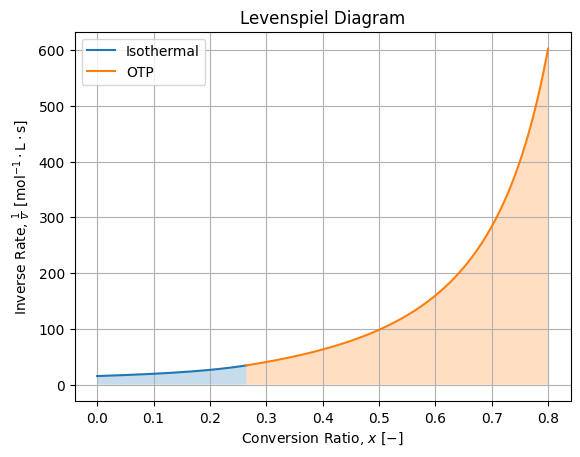

In [38]:
fig, axe = plt.subplots()
axe.plot(xlin2, L2, label="Isothermal")
axe.fill_between(xlin2, L2, alpha=0.25)
axe.plot(xlin3, L3, label="OTP")
axe.fill_between(xlin3, L3, alpha=0.25)
axe.set_title("Levenspiel Diagram")
axe.set_xlabel(r"Conversion Ratio, $x$ $[-]$")
axe.set_ylabel(r"Inverse Rate, $\frac{1}{v}$ $[\mathrm{mol^{-1}\cdot L \cdot s}]$")
axe.legend()
axe.grid()